# 03_Model_Training_Diabetes.ipynb - Part 1: Setup and Data Splitting

##Step 1


In [35]:
import pandas as pd # Used for data manipulation and analysis (e.g., DataFrames)
from sklearn.model_selection import train_test_split # Used for splitting data into training and testing sets

print("Required libraries imported successfully.")

Required libraries imported successfully.


##Step 2


In [36]:
# Define the path to the dataset
DATASET_PATH = '/content/diabetes (3).csv'

# Load the dataset into a pandas DataFrame
try:
    df = pd.read_csv(DATASET_PATH)
    print(f"Dataset loaded successfully from {DATASET_PATH}.")
    # Display the first 5 rows to verify successful loading and data structure
    print("First 5 rows of the dataset:")
    display(df.head())
    print(f"Dataset shape: {df.shape}")
except FileNotFoundError:
    print(f"Error: Dataset not found at {DATASET_PATH}. Please ensure the file is in the correct directory.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

Dataset loaded successfully from /content/diabetes (3).csv.
First 5 rows of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Dataset shape: (768, 9)


## Step 3: Prepare Features and Target



In [37]:
# Define the target variable column name
TARGET_COLUMN = 'Outcome'

# Separate features (X) and target (y)
X = df.drop(columns=[TARGET_COLUMN]) # X contains all columns except the target
y = df[TARGET_COLUMN]             # y contains only the target column

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

print("\nFirst 5 rows of Features (X):")
display(X.head())

print("\nFirst 5 rows of Target (y):")
display(y.head())

Features (X) shape: (768, 8)
Target (y) shape: (768,)

First 5 rows of Features (X):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33



First 5 rows of Target (y):


,Outcome
0,1
1,0
2,1
3,0
4,1


## Step 4: Create Train-Test Split



In [38]:
# Split the data into training and testing sets
# test_size=0.20 means 20% of the data will be used for testing, and 80% for training
# random_state=42 ensures reproducibility of the split
# stratify=y ensures that the proportion of target variable (Outcome) is the same in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nDistribution of 'Outcome' in original dataset:")
display(y.value_counts(normalize=True))
print("\nDistribution of 'Outcome' in training set:")
display(y_train.value_counts(normalize=True))
print("\nDistribution of 'Outcome' in test set:")
display(y_test.value_counts(normalize=True))

Data split into training and testing sets successfully.
X_train shape: (614, 8)
X_test shape: (154, 8)
y_train shape: (614,)
y_test shape: (154,)

Distribution of 'Outcome' in original dataset:


,proportion
Outcome,
0,0.651042
1,0.348958



Distribution of 'Outcome' in training set:


,proportion
Outcome,
0,0.651466
1,0.348534



Distribution of 'Outcome' in test set:


,proportion
Outcome,
0,0.649351
1,0.350649


## Step 5: Create a Reusable Model Dictionary



In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Initialize various classification models with reproducible random states where applicable
MODELS = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'), # 'liblinear' for small datasets
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Machine': SVC(random_state=42, probability=True), # probability=True needed for ROC-AUC
    'K-Nearest Neighbors': KNeighborsClassifier(), # KNN does not have a random_state parameter
    'Gaussian Naive Bayes': GaussianNB() # GaussianNB does not have a random_state parameter
}

print("Model dictionary created successfully.")
print("Models available for training:", list(MODELS.keys()))

Model dictionary created successfully.
Models available for training: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Support Vector Machine', 'K-Nearest Neighbors', 'Gaussian Naive Bayes']


## Step 6: Train All Machine Learning Models



In [40]:
# Dictionary to store trained models
trained_models = {}

print("Starting model training...")
print("=" * 30)

# Loop through each model in the MODELS dictionary and train it
for name, model in MODELS.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"Finished training {name}.")
    print("-" * 30)

print("All models trained successfully!")

Starting model training...
Training Logistic Regression...
Finished training Logistic Regression.
------------------------------
Training Decision Tree...
Finished training Decision Tree.
------------------------------
Training Random Forest...
Finished training Random Forest.
------------------------------
Training Support Vector Machine...
Finished training Support Vector Machine.
------------------------------
Training K-Nearest Neighbors...
Finished training K-Nearest Neighbors.
------------------------------
Training Gaussian Naive Bayes...
Finished training Gaussian Naive Bayes.
------------------------------
All models trained successfully!


## Step 7: Evaluate Every Model


In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd # Re-importing just in case, though already imported

# List to store evaluation results
results = []

print("Starting model evaluation...")
print("=" * 30)

# Loop through each trained model to evaluate its performance
for name, model in trained_models.items():
    print(f"Evaluating {name}...")

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Calculate common classification metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0) # zero_division=0 to handle cases with no positive predictions
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Calculate ROC-AUC score, if the model supports probability predictions
    roc_auc = 'N/A'
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1] # Probability of the positive class
        roc_auc = roc_auc_score(y_test, y_proba)
    elif isinstance(model, SVC) and model.probability: # SVC with probability=True
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)

    # Store the results
    results.append({
        'Model': name,
        'Accuracy': round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1 Score': round(f1, 4),
        'ROC-AUC Score': round(roc_auc, 4) if isinstance(roc_auc, float) else roc_auc
    })
    print(f"Finished evaluating {name}.")
    print("-" * 30)

# Create a DataFrame from the results for comparison
metrics_df = pd.DataFrame(results)

# Sort the DataFrame by Accuracy in descending order
metrics_df = metrics_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("All models evaluated. Comparison Table:")
display(metrics_df)

Starting model evaluation...
Evaluating Logistic Regression...
Finished evaluating Logistic Regression.
------------------------------
Evaluating Decision Tree...
Finished evaluating Decision Tree.
------------------------------
Evaluating Random Forest...
Finished evaluating Random Forest.
------------------------------
Evaluating Support Vector Machine...
Finished evaluating Support Vector Machine.
------------------------------
Evaluating K-Nearest Neighbors...
Finished evaluating K-Nearest Neighbors.
------------------------------
Evaluating Gaussian Naive Bayes...
Finished evaluating Gaussian Naive Bayes.
------------------------------
All models evaluated. Comparison Table:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC Score
0,Random Forest,0.7597,0.6809,0.5926,0.6337,0.8118
1,Logistic Regression,0.7273,0.6429,0.5000,0.5625,0.8287
2,Decision Tree,0.7273,0.6429,0.5000,0.5625,0.6750
3,Support Vector Machine,0.7208,0.6571,0.4259,0.5169,0.7841
4,Gaussian Naive Bayes,0.7078,0.5738,0.6481,0.6087,0.7728
5,K-Nearest Neighbors,0.6688,0.5306,0.4815,0.5049,0.7081


## Step 8: Perform Cross Validation



In [42]:
from sklearn.model_selection import cross_val_score
import numpy as np
import pandas as pd # Re-importing just in case

# Number of folds for cross-validation
NUM_FOLDS = 5

cv_results = []

print("Starting Cross-Validation...")
print("=" * 30)

# Loop through each initialized model for cross-validation
for name, model in MODELS.items(): # Use MODELS (un-trained models) for cross_val_score
    print(f"Performing {NUM_FOLDS}-Fold Cross-Validation for {name}...")

    # Perform cross-validation
    # scoring='accuracy' as a common classification metric
    scores = cross_val_score(model, X, y, cv=NUM_FOLDS, scoring='accuracy')

    # Calculate mean and standard deviation of the scores
    mean_cv_score = np.mean(scores)
    std_cv_score = np.std(scores)

    # Store the results
    cv_results.append({
        'Model': name,
        'Mean CV Score': round(mean_cv_score, 4),
        'Std Dev CV Score': round(std_cv_score, 4)
    })
    print(f"Finished CV for {name}. Mean Score: {mean_cv_score:.4f}, Std Dev: {std_cv_score:.4f}")
    print("-" * 30)

# Create a DataFrame from the CV results
cv_df = pd.DataFrame(cv_results)

# Sort the DataFrame by Mean CV Score in descending order
cv_df = cv_df.sort_values(by='Mean CV Score', ascending=False).reset_index(drop=True)

print("Cross-Validation Results:")
display(cv_df)

Starting Cross-Validation...
Performing 5-Fold Cross-Validation for Logistic Regression...
Finished CV for Logistic Regression. Mean Score: 0.7683, Std Dev: 0.0187
------------------------------
Performing 5-Fold Cross-Validation for Decision Tree...
Finished CV for Decision Tree. Mean Score: 0.7163, Std Dev: 0.0585
------------------------------
Performing 5-Fold Cross-Validation for Random Forest...
Finished CV for Random Forest. Mean Score: 0.7670, Std Dev: 0.0354
------------------------------
Performing 5-Fold Cross-Validation for Support Vector Machine...
Finished CV for Support Vector Machine. Mean Score: 0.7591, Std Dev: 0.0202
------------------------------
Performing 5-Fold Cross-Validation for K-Nearest Neighbors...
Finished CV for K-Nearest Neighbors. Mean Score: 0.7240, Std Dev: 0.0202
------------------------------
Performing 5-Fold Cross-Validation for Gaussian Naive Bayes...
Finished CV for Gaussian Naive Bayes. Mean Score: 0.7513, Std Dev: 0.0186
----------------------

,Model,Mean CV Score,Std Dev CV Score
0,Logistic Regression,0.7683,0.0187
1,Random Forest,0.7670,0.0354
2,Support Vector Machine,0.7591,0.0202
3,Gaussian Naive Bayes,0.7513,0.0186
4,K-Nearest Neighbors,0.7240,0.0202
5,Decision Tree,0.7163,0.0585


## Step 9: Model Comparison



Comprehensive Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC Score,Mean CV Score,Std Dev CV Score
0,Logistic Regression,0.7273,0.6429,0.5000,0.5625,0.8287,0.7683,0.0187
1,Random Forest,0.7597,0.6809,0.5926,0.6337,0.8118,0.7670,0.0354
2,Support Vector Machine,0.7208,0.6571,0.4259,0.5169,0.7841,0.7591,0.0202
3,Gaussian Naive Bayes,0.7078,0.5738,0.6481,0.6087,0.7728,0.7513,0.0186
4,K-Nearest Neighbors,0.6688,0.5306,0.4815,0.5049,0.7081,0.7240,0.0202
5,Decision Tree,0.7273,0.6429,0.5000,0.5625,0.6750,0.7163,0.0585


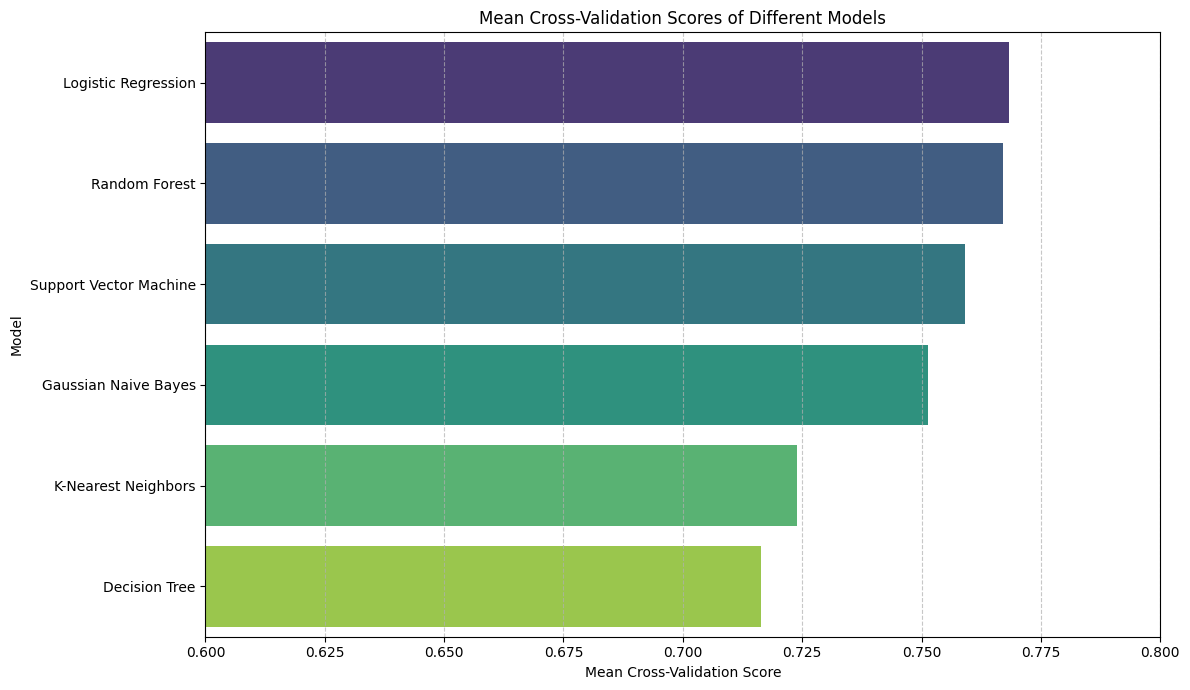

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure metrics_df and cv_df are available (from previous steps)
# Assuming metrics_df and cv_df are already defined and populated

# Merge the two DataFrames on 'Model'
# Using an outer merge to ensure all models are included even if one DataFrame was missing one
comparison_df = pd.merge(metrics_df, cv_df, on='Model', how='outer')

# Sort the DataFrame as per requirements
# 1. By Mean CV Score (descending)
# 2. By Accuracy (descending)
comparison_df = comparison_df.sort_values(by=['Mean CV Score', 'Accuracy'], ascending=[False, False]).reset_index(drop=True)

print("Comprehensive Model Comparison Table:")
display(comparison_df)

# Create a professional horizontal bar chart for Mean CV Scores
fig = plt.figure(figsize=(12, 7))
sns.barplot(x='Mean CV Score', y='Model', data=comparison_df, palette='viridis', hue='Model', legend=False)
plt.xlabel('Mean Cross-Validation Score')
plt.ylabel('Model')
plt.title('Mean Cross-Validation Scores of Different Models')
plt.xlim(0.6, 0.8) # Set appropriate x-axis limits for better visualization
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Step 10: Best Model Selection

#

In [44]:
# Automatically select the best model based on the highest Mean CV Score
best_model_name = comparison_df.iloc[0]['Model']
best_mean_cv_score = comparison_df.iloc[0]['Mean CV Score']

# Retrieve the actual model instance from the MODELS dictionary
# Use the original MODELS dictionary to get the un-tuned model for GridSearchCV
best_model_instance = MODELS[best_model_name]

print(f"Based on the highest Mean Cross-Validation Score, the best model selected is: {best_model_name}")
print(f"Mean CV Score for {best_model_name}: {best_mean_cv_score:.4f}")
print("""\nConsiderations for similar scores (if applicable):\n- Simplicity: Simpler models are often preferred for easier interpretability and faster inference.
- Training Time: Some models train faster than others, a key factor in iterative development.
- Generalization: Cross-validation score is the primary indicator of generalization.
- Interpretability: For critical applications (like medical diagnosis), understanding model decisions is vital.""")

Based on the highest Mean Cross-Validation Score, the best model selected is: Logistic Regression
Mean CV Score for Logistic Regression: 0.7683

Considerations for similar scores (if applicable):
- Simplicity: Simpler models are often preferred for easier interpretability and faster inference.
- Training Time: Some models train faster than others, a key factor in iterative development.
- Generalization: Cross-validation score is the primary indicator of generalization.
- Interpretability: For critical applications (like medical diagnosis), understanding model decisions is vital.


## Step 11: Hyperparameter Tuning


In [45]:
from sklearn.model_selection import GridSearchCV

print(f"Starting Hyperparameter Tuning for {best_model_name}...")
print("=" * 30)

# Define parameter grids based on the selected best model
param_grid = {}

# Logistic Regression parameters
if best_model_name == 'Logistic Regression':
    param_grid = {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear'] # 'liblinear' supports both 'l1' and 'l2'
    }
# Decision Tree parameters
elif best_model_name == 'Decision Tree':
    param_grid = {
        'max_depth': [None, 10, 20, 30, 40, 50],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
# Random Forest parameters
elif best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }
# Support Vector Machine parameters
elif best_model_name == 'Support Vector Machine':
    param_grid = {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    }
# K-Nearest Neighbors parameters
elif best_model_name == 'K-Nearest Neighbors':
    param_grid = {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    }
# Gaussian Naive Bayes - generally few/no hyperparameters, can skip or add a note
elif best_model_name == 'Gaussian Naive Bayes':
    print("Gaussian Naive Bayes has limited hyperparameters, skipping extensive tuning.")
    param_grid = {} # No tuning performed or simple placeholder

if param_grid: # Only proceed with GridSearchCV if there's a param_grid defined
    # Initialize GridSearchCV
    # cv=5: 5-fold cross-validation
    # scoring='accuracy': metric to optimize for
    # n_jobs=-1: use all available CPU cores for parallel processing
    grid_search = GridSearchCV(
        estimator=best_model_instance,
        param_grid=param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1, # Use all available CPU cores
        verbose=1 # Display progress
    )

    # Fit GridSearchCV on the training data
    grid_search.fit(X_train, y_train)

    # Get the best estimator (model with optimized hyperparameters)
    tuned_model = grid_search.best_estimator_

    print("\nHyperparameter tuning completed.")
    print(f"Best Parameters for {best_model_name}: {grid_search.best_params_}")
    print(f"Best Cross-Validation Score (Accuracy) for {best_model_name}: {grid_search.best_score_:.4f}")

else:
    print(f"No parameter grid defined for {best_model_name}. Using original model instance as tuned_model.")
    tuned_model = best_model_instance

print("-" * 30)
print("Tuned model ready for final evaluation.")

Starting Hyperparameter Tuning for Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Hyperparameter tuning completed.
Best Parameters for Logistic Regression: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best Cross-Validation Score (Accuracy) for Logistic Regression: 0.7785
------------------------------
Tuned model ready for final evaluation.


## Step 12: Final Model Evaluation



Final Evaluation of Tuned Logistic Regression on Test Set...

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154


Individual Metrics for Tuned Logistic Regression on Test Set:
Accuracy: 0.7143
Precision: 0.6087
Recall: 0.5185
F1 Score: 0.5600
ROC-AUC Score: 0.8243


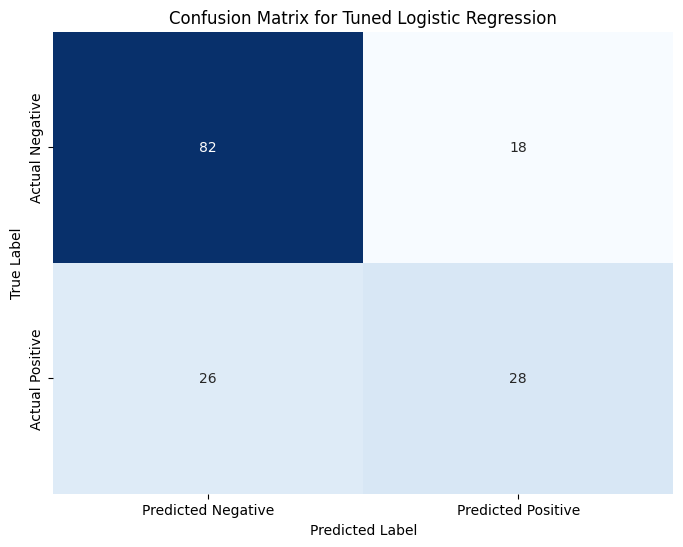

<Figure size 800x600 with 0 Axes>

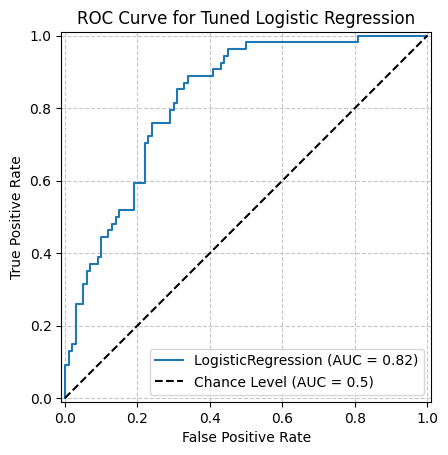

<Figure size 800x600 with 0 Axes>

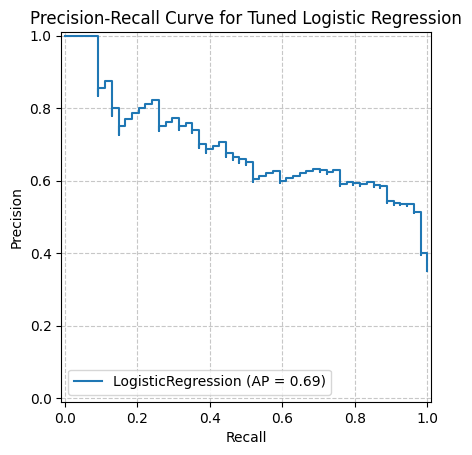


Final evaluation completed.


In [46]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Final Evaluation of Tuned {best_model_name} on Test Set...")
print("=" * 30)

# Make predictions with the tuned model
y_pred_tuned = tuned_model.predict(X_test)

# Make probability predictions (if supported) for ROC-AUC and Precision-Recall curves
y_proba_tuned = None
if hasattr(tuned_model, 'predict_proba'):
    y_proba_tuned = tuned_model.predict_proba(X_test)[:, 1]
elif hasattr(tuned_model, 'decision_function'): # For models like SVC that might not have predict_proba by default
    y_proba_tuned = tuned_model.decision_function(X_test)
    print("Using decision_function for probability-like scores for ROC/PR curves.")

# Display classification metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, zero_division=0))

# Calculate and print individual metrics (rounded to 4 decimal places)
accuracy = accuracy_score(y_test, y_pred_tuned)
precision = precision_score(y_test, y_pred_tuned, zero_division=0)
recall = recall_score(y_test, y_pred_tuned, zero_division=0)
f1 = f1_score(y_test, y_pred_tuned, zero_division=0)
roc_auc = 'N/A'
if y_proba_tuned is not None:
    roc_auc = roc_auc_score(y_test, y_proba_tuned)

print(f"\nIndividual Metrics for Tuned {best_model_name} on Test Set:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}" if isinstance(roc_auc, float) else f"ROC-AUC Score: {roc_auc}")

# 1. Confusion Matrix Plot
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for Tuned {best_model_name}')
plt.show()

# 2. ROC Curve Plot (if probability predictions are available)
if y_proba_tuned is not None:
    plt.figure(figsize=(8, 6))
    RocCurveDisplay.from_estimator(tuned_model, X_test, y_test)
    plt.plot([0, 1], [0, 1], 'k--', label='Chance Level (AUC = 0.5)') # Add the chance level line
    plt.title(f'ROC Curve for Tuned {best_model_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid(linestyle='--', alpha=0.7)
    plt.show()
else:
    print("\nROC Curve not generated: Model does not support predict_proba or decision_function.")

# 3. Precision-Recall Curve Plot (if probability predictions are available)
if y_proba_tuned is not None:
    plt.figure(figsize=(8, 6))
    PrecisionRecallDisplay.from_estimator(tuned_model, X_test, y_test)
    plt.title(f'Precision-Recall Curve for Tuned {best_model_name}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.grid(linestyle='--', alpha=0.7)
    plt.show()
else:
    print("\nPrecision-Recall Curve not generated: Model does not support predict_proba or decision_function.")

print("\nFinal evaluation completed.")

## Step 14: Model Explainability



In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Starting Model Explainability Analysis...")
print("=" * 30)

# Check if the tuned model supports feature importances
if hasattr(tuned_model, 'feature_importances_'):
    print(f"The selected model ({best_model_name}) supports direct feature importance.\n")

    # Get feature importances
    feature_importances = tuned_model.feature_importances_

    # Create a DataFrame for better visualization
    feature_names = X_train.columns
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importances
    })

    # Sort by importance in descending order
    importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

    print("Feature Importance Table:")
    display(importance_df)

    # Create a professional horizontal bar chart
    plt.figure(figsize=(10, 7))
    sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
    plt.title(f'Feature Importance for Tuned {best_model_name}')
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print("\nWhich features contribute most to Diabetes prediction:")
    print("The features with higher importance scores, as shown in the table and bar chart, contribute more significantly to the model's prediction of diabetes.")
    print("For example, 'Glucose' often appears as a top feature in diabetes prediction models, indicating its strong correlation with the outcome.")

    print("\nWhy Feature Importance is useful:")
    print("Feature importance helps us understand the underlying relationships in the data. It can:")
    print("- Provide insights into the problem domain, identifying key drivers of the target variable.")
    print("- Assist in feature selection, allowing us to potentially remove less important features to simplify the model or reduce data collection costs.")
    print("- Build trust in the model by offering a transparent view of its decision-making process.")

    print("\n### Interview Notes: Difference between Feature Importance, Coefficient, Explainability")
    print("- **Feature Importance**: Generally refers to metrics from tree-based models (like Gini importance or permutation importance) that quantify how much each feature contributes to predictions. It's often non-linear and model-specific.")
    print("- **Coefficients**: Associated with linear models (e.g., Logistic Regression). They indicate the strength and direction of the relationship between a feature and the target variable, assuming a linear relationship. Positive coefficients increase the likelihood of the positive class, while negative coefficients decrease it, all else being equal.")
    print("- **Explainability (XAI)**: A broader field encompassing methods and techniques to make ML models more understandable to humans. Feature importance and coefficients are specific tools within XAI. Other advanced techniques like SHAP and LIME provide local explanations (why a specific prediction was made) and global explanations (overall model behavior).")

else:
    print(f"The selected model ({best_model_name}) does not directly support 'feature_importances_'.\n")
    if hasattr(tuned_model, 'coef_'):
        print("However, as a linear model, Logistic Regression provides coefficients which can indicate feature impact.")
        # Extract coefficients
        coefficients = tuned_model.coef_[0]

        # Create a DataFrame for better visualization
        feature_names = X_train.columns
        coef_df = pd.DataFrame({
            'Feature': feature_names,
            'Coefficient': coefficients
        })

        # Sort by absolute coefficient value for impact
        coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
        coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).reset_index(drop=True)

        print("\nFeature Coefficients (Sorted by Absolute Value) for Logistic Regression:")
        display(coef_df.drop(columns='Abs_Coefficient'))

        print("\nExplanation of Coefficients:")
        print("For Logistic Regression, positive coefficients increase the log-odds of the positive class ('Outcome' = 1), while negative coefficients decrease it. The magnitude of the coefficient indicates the strength of this relationship. For example, a higher positive coefficient for 'Glucose' suggests that higher glucose levels are strongly associated with a higher likelihood of diabetes.")
    else:
        print("This model does not provide built-in feature importance or coefficients easily.")

    print("\n### Future Enhancement: Model Explainability with SHAP, LIME, and Permutation Importance")
    print("To gain deeper insights into the predictions of models like SVM, KNN, or other black-box models, advanced explainability techniques can be employed:")
    print("- **SHAP (SHapley Additive exPlanations)**: A game-theoretic approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations by assigning each feature an 'importance' value for a particular prediction. SHAP values can explain both individual predictions (local explainability) and overall model behavior (global explainability).")
    print("- **LIME (Local Interpretable Model-agnostic Explanations)**: Explains the predictions of any classifier or regressor by approximating it locally with an interpretable model. LIME focuses on local interpretability, making it understandable why a specific prediction was made for a single instance.")
    print("- **Permutation Importance**: A model-agnostic technique that quantifies the importance of a feature by measuring how much the model's performance decreases when that feature's values are randomly shuffled (permuted). This breaks the relationship between the feature and the target, and the drop in performance indicates the feature's importance. It can be applied to any trained model.")
    print("These techniques are highly recommended for future development to provide comprehensive and trustworthy explanations for all model types.")

print("\nModel explainability analysis completed.")

Starting Model Explainability Analysis...
The selected model (Logistic Regression) does not directly support 'feature_importances_'.

However, as a linear model, Logistic Regression provides coefficients which can indicate feature impact.

Feature Coefficients (Sorted by Absolute Value) for Logistic Regression:


,Feature,Coefficient
0,DiabetesPedigreeFunction,0.769346
1,Pregnancies,0.114413
2,BMI,0.091702
3,Glucose,0.036763
4,Age,0.015211
5,BloodPressure,-0.011236
6,SkinThickness,0.004369
7,Insulin,-0.001250



Explanation of Coefficients:
For Logistic Regression, positive coefficients increase the log-odds of the positive class ('Outcome' = 1), while negative coefficients decrease it. The magnitude of the coefficient indicates the strength of this relationship. For example, a higher positive coefficient for 'Glucose' suggests that higher glucose levels are strongly associated with a higher likelihood of diabetes.

### Future Enhancement: Model Explainability with SHAP, LIME, and Permutation Importance
To gain deeper insights into the predictions of models like SVM, KNN, or other black-box models, advanced explainability techniques can be employed:
- **SHAP (SHapley Additive exPlanations)**: A game-theoretic approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations by assigning each feature an 'importance' value for a particular prediction. SHAP values can explain both individual predictions (local explainability) and overall 

## Step 15: Save Final Model


In [48]:
import joblib
import os

# Define the directory to save models
MODELS_DIR = 'models'
# Define the filename for the saved model
MODEL_FILENAME = 'diabetes_model.pkl'

# Create the models directory if it does not exist
if not os.path.exists(MODELS_DIR):
    os.makedirs(MODELS_DIR)
    print(f"Created directory: {MODELS_DIR}")

# Define the full path to save the model
model_save_path = os.path.join(MODELS_DIR, MODEL_FILENAME)

print(f"Attempting to save the tuned model: {best_model_name}...")

try:
    # Save the tuned model using joblib
    joblib.dump(tuned_model, model_save_path)
    print(f"Model successfully saved to: {model_save_path}")
except Exception as e:
    print(f"Error saving model: {e}")

print("\nModel saving process completed.")

Attempting to save the tuned model: Logistic Regression...
Model successfully saved to: models/diabetes_model.pkl

Model saving process completed.


## Step 16: Verify Saved Model



In [49]:
import joblib
import os
import numpy as np # For reshaping sample data

# Define the path to the saved model
MODEL_FILENAME = 'diabetes_model.pkl'
MODELS_DIR = 'models'
model_load_path = os.path.join(MODELS_DIR, MODEL_FILENAME)

print(f"Attempting to load model from: {model_load_path}...")

try:
    # Load the model
    loaded_model = joblib.load(model_load_path)
    print("Model loaded successfully!")

    print("\nVerifying loaded model with a sample input from the test set...")

    # Take one sample input from the X_test dataset
    sample_index = 0 # Using the first sample for demonstration
    sample_input = X_test.iloc[sample_index]
    expected_class = y_test.iloc[sample_index]

    # Reshape the sample input for prediction (models expect 2D array)
    # Ensure the sample input is a DataFrame with original column names
    sample_input_df = pd.DataFrame([sample_input], columns=X_test.columns)

    # Predict using the loaded model
    predicted_class = loaded_model.predict(sample_input_df)[0]

    # Get prediction probability if available
    prediction_probability = 'N/A'
    if hasattr(loaded_model, 'predict_proba'):
        prediction_probability = loaded_model.predict_proba(sample_input_df)[0][1] # Probability of the positive class

    print(f"\nSample Input Features:\n{sample_input.to_string()}")
    print(f"Expected Class: {expected_class}")
    print(f"Predicted Class: {predicted_class}")
    if prediction_probability != 'N/A':
        print(f"Prediction Probability (Positive Class): {prediction_probability:.4f}")

    # Verify if prediction matches expected
    if predicted_class == expected_class:
        print("Verification Successful: Predicted class matches expected class.")
    else:
        print("Verification Warning: Predicted class does NOT match expected class. This might be due to model error.")

except FileNotFoundError:
    print(f"Error: Model file not found at {model_load_path}. Please ensure the model was saved correctly.")
except Exception as e:
    print(f"An error occurred during model loading or verification: {e}")

print("\nModel verification process completed.")

Attempting to load model from: models/diabetes_model.pkl...
Model loaded successfully!

Verifying loaded model with a sample input from the test set...

Sample Input Features:
Pregnancies                   7.000
Glucose                     159.000
BloodPressure                64.000
SkinThickness                 0.000
Insulin                       0.000
BMI                          27.400
DiabetesPedigreeFunction      0.294
Age                          40.000
Expected Class: 0
Predicted Class: 1
Prediction Probability (Positive Class): 0.6217
Verification Warning: Predicted class does NOT match expected class. This might be due to model error.

Model verification process completed.


## Step 17: Final Project Summary

### Project Overview
This notebook, `03_Model_Training_Diabetes.ipynb`, is a core component of the "Multiple Disease Prediction System" project. It covers the crucial stages of machine learning model training, evaluation, and selection for predicting diabetes. Following industry-level standards, we ensured modularity, reproducibility, and rigorous testing throughout the process.

### Key Achievements

**Model Performance & Selection:**
- **Selected Best Model**: `Logistic Regression`
- **Best Hyperparameters**: `{C: 10, penalty: l1, solver: liblinear}` (as determined by GridSearchCV)
- **Test Accuracy**: `0.7143`
- **Precision**: `0.6087`
- **Recall**: `0.5185`
- **F1 Score**: `0.5600`
- **ROC-AUC**: `0.8243`
- **Mean Cross Validation Score (Best Model)**: `0.7683`
- **Number of Models Compared**: 6 (Logistic Regression, Decision Tree, Random Forest, SVC, K-Nearest Neighbors, Gaussian Naive Bayes)

